## To compare results of different thresholds

### Created by Shu, 20250921---

<br />
<br />
<br />


### Detection rate:

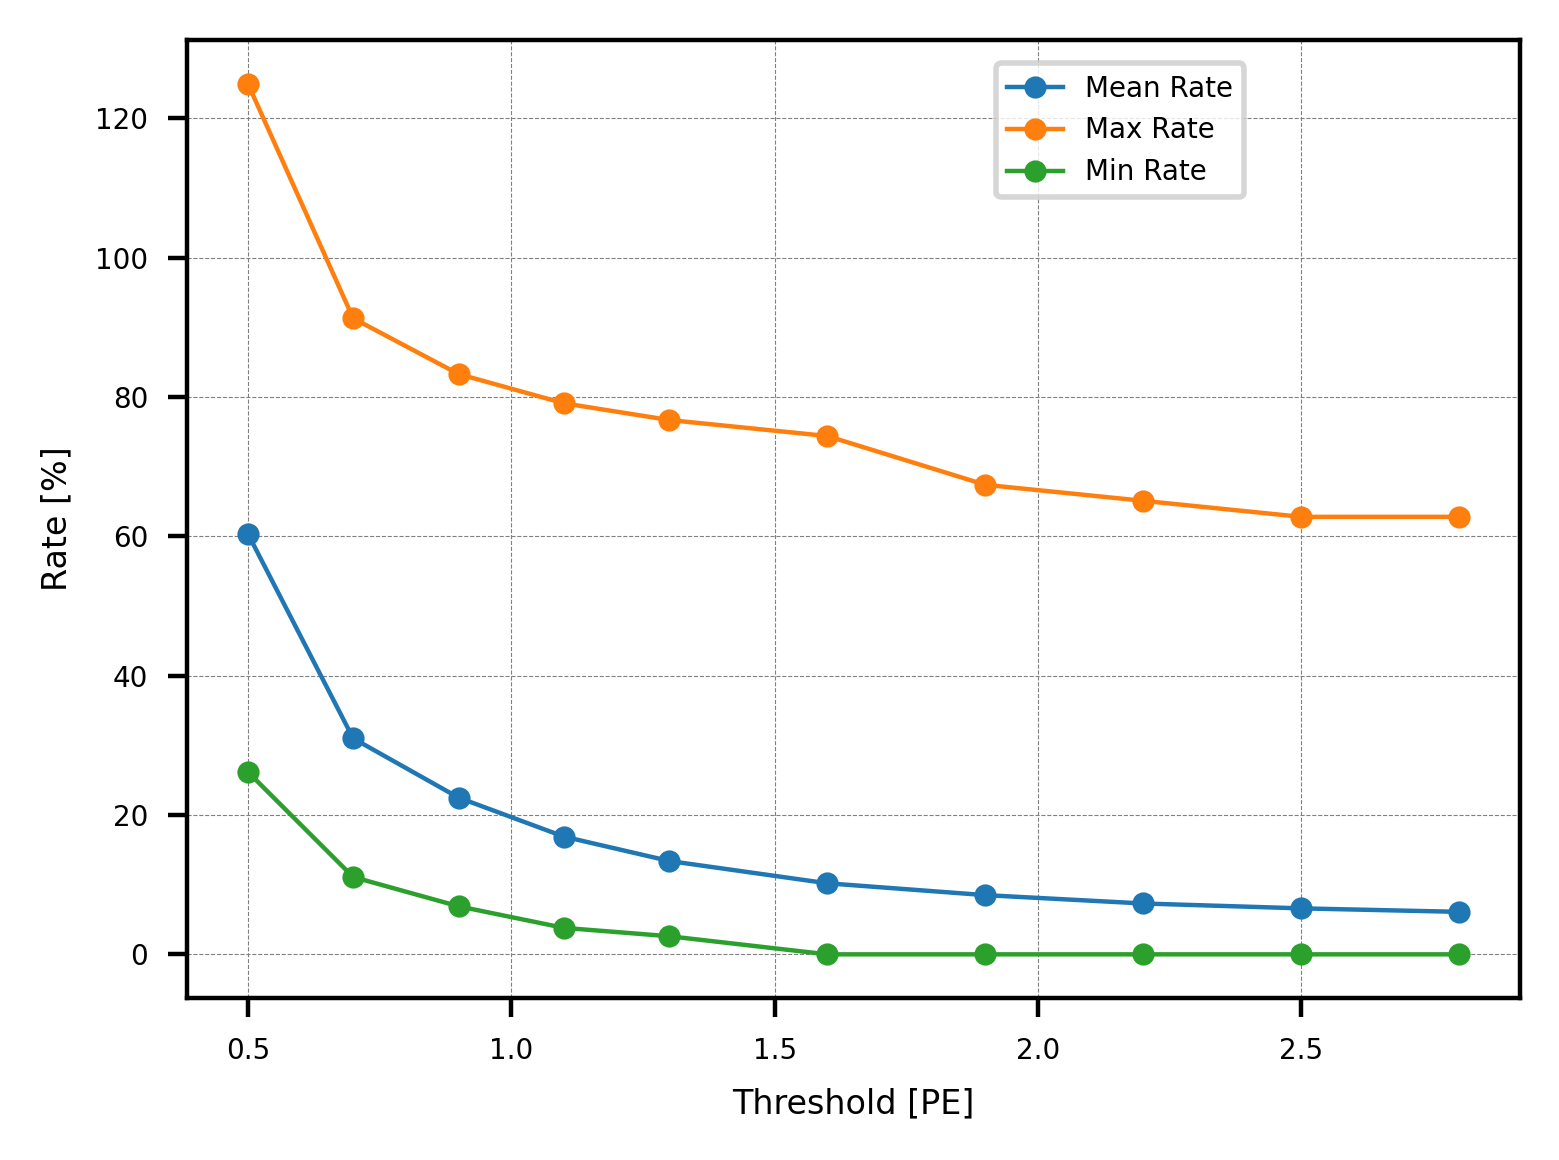

In [1]:
import matplotlib.pyplot as plt
import numpy as np

thre = [0.5, 0.7, 0.9, 1.1, 1.3, 1.6, 1.9, 2.2, 2.5, 2.8]

mean_rate = [60.4, 31.0, 22.5, 16.9, 13.4, 10.2, 8.5, 7.3, 6.6, 6.1]
max_rate = [125, 91.3, 83.3, 79.1, 76.7, 74.4, 67.4, 65.1, 62.8, 62.8]
min_rate = [26.2, 11.1, 6.9, 3.8, 2.6, 0, 0, 0, 0, 0]

# Plot------
plt.figure(figsize=(4,3),dpi=400)
plt.plot(thre, mean_rate, 'o-', linewidth=0.8, markersize=3, label='Mean Rate')
plt.plot(thre, max_rate, 'o-', linewidth=0.8, markersize=3, label='Max Rate')
plt.plot(thre, min_rate, 'o-', linewidth=0.8, markersize=3, label='Min Rate')

plt.xlabel('Threshold')
plt.ylabel('Rate [%]')
plt.xlabel('Threshold [PE]', fontsize=6)
plt.ylabel('Rate [%]', fontsize=6)
plt.tick_params(labelsize=5)
#plt.title('Rates vs Threshold')
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=6, markerscale=1, ncol=1, prop={'size':5})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.tight_layout()
plt.show()







<br />
<br />
<br />


### Single-exponential fittings of various thresholds:

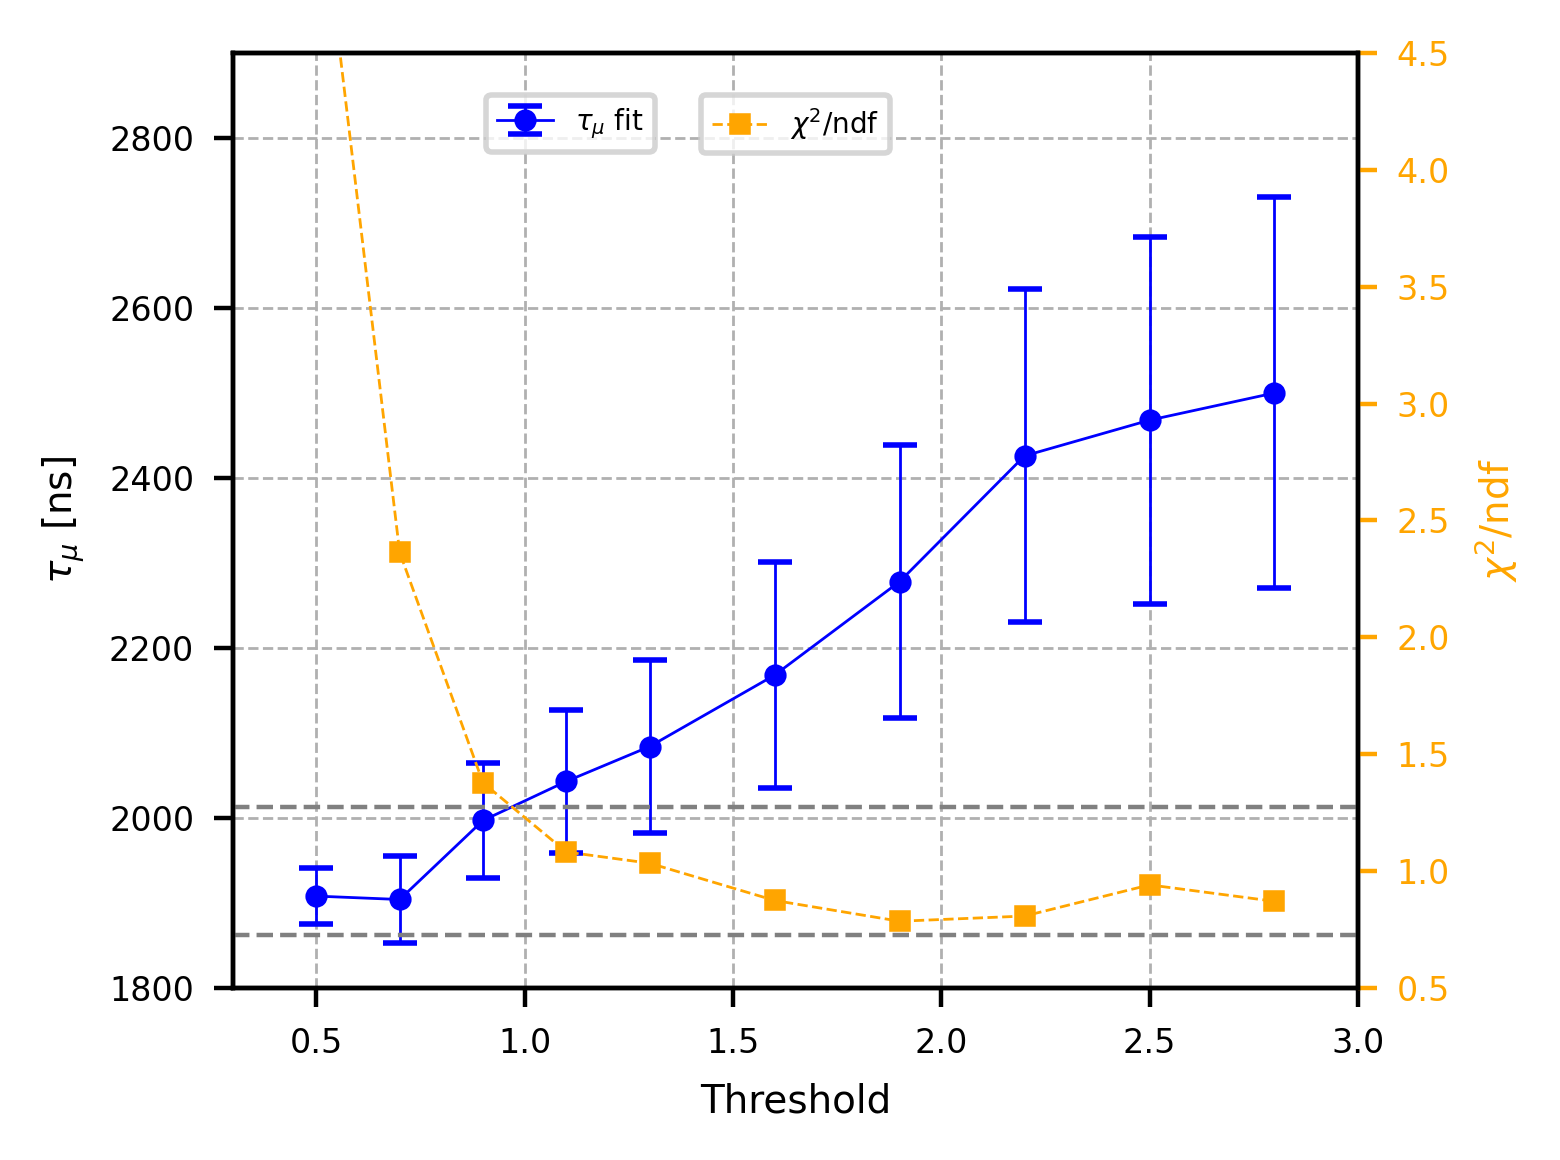

In [3]:
import matplotlib.pyplot as plt
import numpy as np

thre = [0.5, 0.7, 0.9, 1.1, 1.3, 1.6, 1.9, 2.2, 2.5, 2.8]
events = [6856, 3525, 2551, 1914, 1517, 1159, 968, 825, 754, 687]
tau_fit = [1908, 1904, 1997, 2043, 2084, 2168, 2278, 2426, 2468, 2500]
tau_unc = [33, 51, 68, 84, 102, 133, 161, 196, 216, 230]
chi2_ndf = [144.27, 63.8, 37.2, 29.2, 27.9, 23.6, 21.2, 21.8, 25.4, 23.5]
chi2_ndf = np.array(chi2_ndf) / 27


#Drawing------------------------------------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

# Left y-axis: τ fit with uncertainties
ax1.errorbar(
    thre, tau_fit, yerr=tau_unc, fmt='o-', color='blue', linewidth=0.5,
    markersize=3, capsize=3, label=r'$\tau_{\mu}$ fit'
)
ax1.set_xlabel('Threshold', fontsize=7)
ax1.set_ylabel(r'$\tau_{\mu}$ [ns]', fontsize=7)
ax1.set_ylim(1800, 2900)
ax1.set_xlim(0.3, 3.0)
ax1.tick_params(labelsize=6)
ax1.grid(True, linestyle='--', linewidth=0.5)

# Right y-axis: χ²/ndf
ax2 = ax1.twinx()
ax2.plot(
    thre, chi2_ndf, 's--', color='orange', linewidth=0.5,
    markersize=3, label=r'$\chi^2/\mathrm{ndf}$'
)


y2_Nsigma = (27 - np.sqrt(54)) / 27
y2_Psigma = (27 + np.sqrt(54)) / 27
ax2.hlines(y=y2_Nsigma, xmin=0.3, xmax=3, color='gray', linestyle='--', linewidth=0.8)
ax2.hlines(y=y2_Psigma, xmin=0.3, xmax=3, color='gray', linestyle='--', linewidth=0.8)


ax2.set_ylabel(r'$\chi^2/\mathrm{ndf}$', fontsize=7, color='orange')
ax2.set_ylim(0.5, 4.5)
ax2.tick_params(axis='y', labelsize=6, colors='orange')


# Legends
ax1.legend(loc='upper center', bbox_to_anchor=(0.3, 0.97), fontsize=8, markerscale=1, ncol=1, prop={'size':5})
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 0.97), fontsize=8, markerscale=1, ncol=1, prop={'size':5})


# Layout
plt.tight_layout()
plt.show()